The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

                             RELATÓRIO ACUMULATIVO                              
Modelo                    | Prec (%)   | Rec (%)    | F1 (%)    
--------------------------------------------------------------------------------
AdaptiveRandomForest      |    99.96   |    99.92   |    99.94
HoeffdingTree             |    99.90   |    99.99   |    99.95



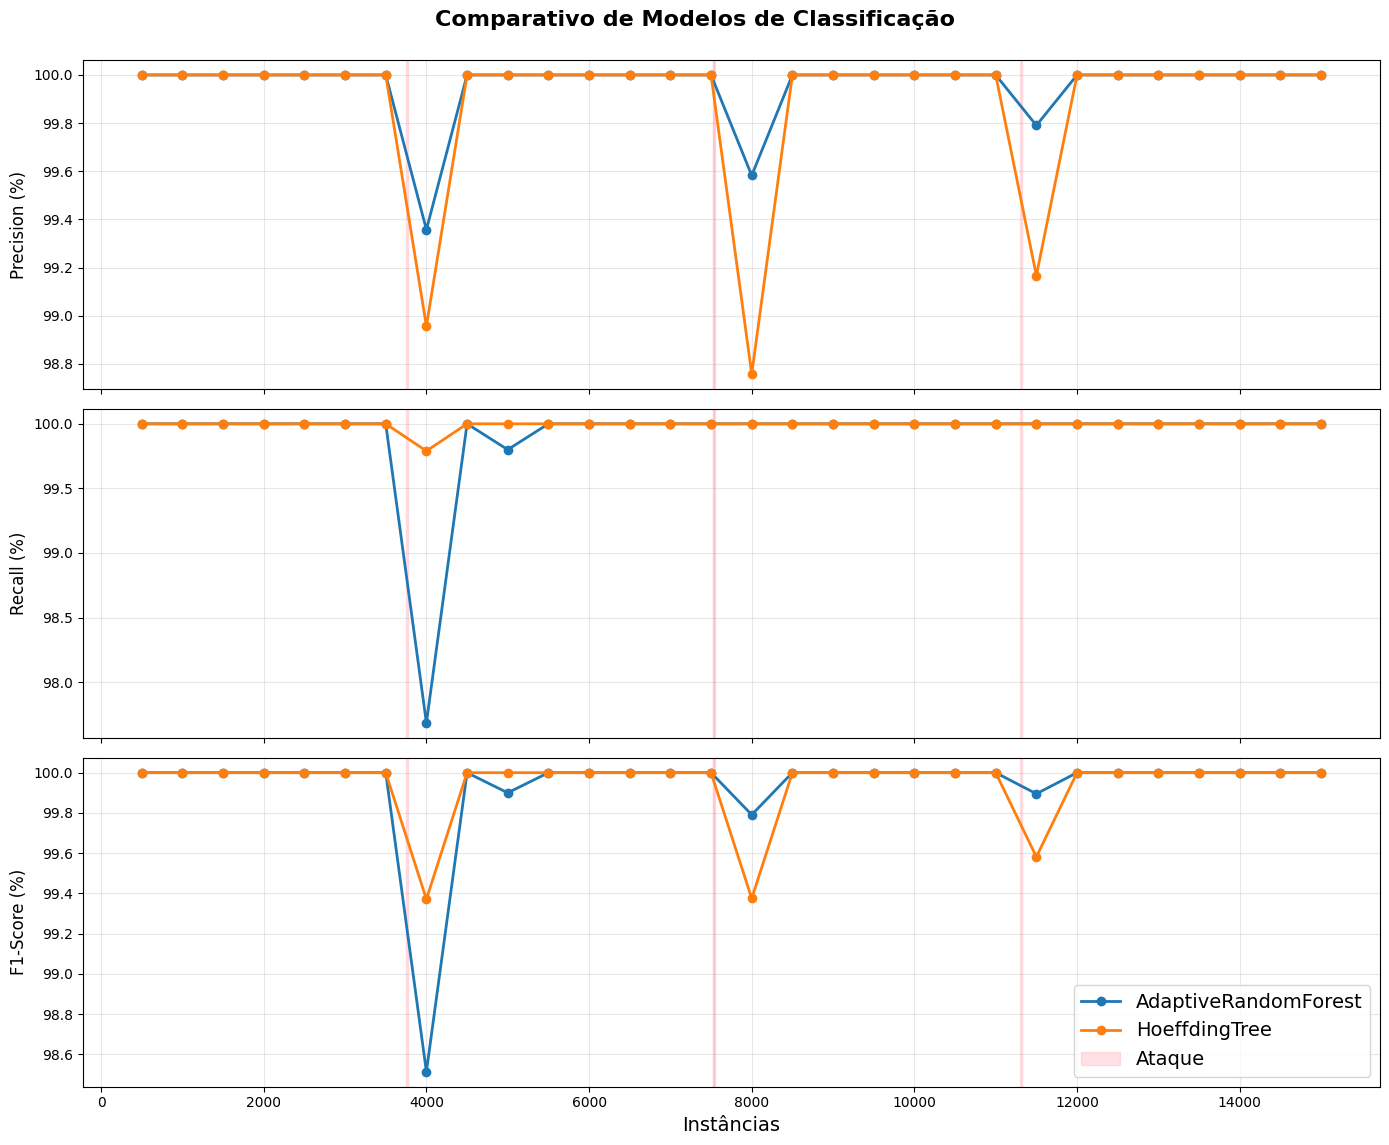

In [ ]:
%load_ext autoreload
%autoreload 2

from src.Classification.Models import get_classification_models
from src.Classification.Pipeline import ClassificationExperimentRunner
from src.Data.Processor import DataStreamProcessor
import pandas as pd

# Instancia o objeto
processor = DataStreamProcessor(logging=False)
runner = ClassificationExperimentRunner()

df = pd.read_csv('data/15k/Consistência/Consistência_25.csv')
# df = pd.read_csv('data/15k/Consistência/Consistência_250.csv')
# df = pd.read_csv('data/15k/Consistência/Consistência_500.csv')
# df = pd.read_csv('data/15k/Consistência/Consistência_1000.csv')
# df = pd.read_csv('data/15k/Consistência/Consistência_2000.csv')

stream, targets, features = processor.create_stream(
    df=df, 
    target_label_col='Label', 
    binary_label=True, 
    normalize_method="StandardScaler", 
    threshold_var=0.001,
    threshold_corr=0.85,
    top_n_features=None,
    return_stream=True,
    extra_ignore_cols=['Source IP', 'Source Port','Destination IP','Destination Port','Protocol'],
    imputation_method='mediana'
)

# Obter modelos
modelos = get_classification_models(stream.get_schema(), selected_models=['ARF', 'HT'])

# Treinar e avaliar os modelos
results, attacks = runner.run_experiments(stream, modelos, window_size=500, logging=False)
runner.print_metrics(results)
runner.plot(results, attacks, title="Comparativo de Modelos de Classificação")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

                             RELATÓRIO ACUMULATIVO                              
Modelo                    | Prec (%)   | Rec (%)    | F1 (%)    
--------------------------------------------------------------------------------
AdaptiveRandomForest      |    99.85   |    99.70   |    99.77
HoeffdingTree             |    98.18   |    99.50   |    98.84



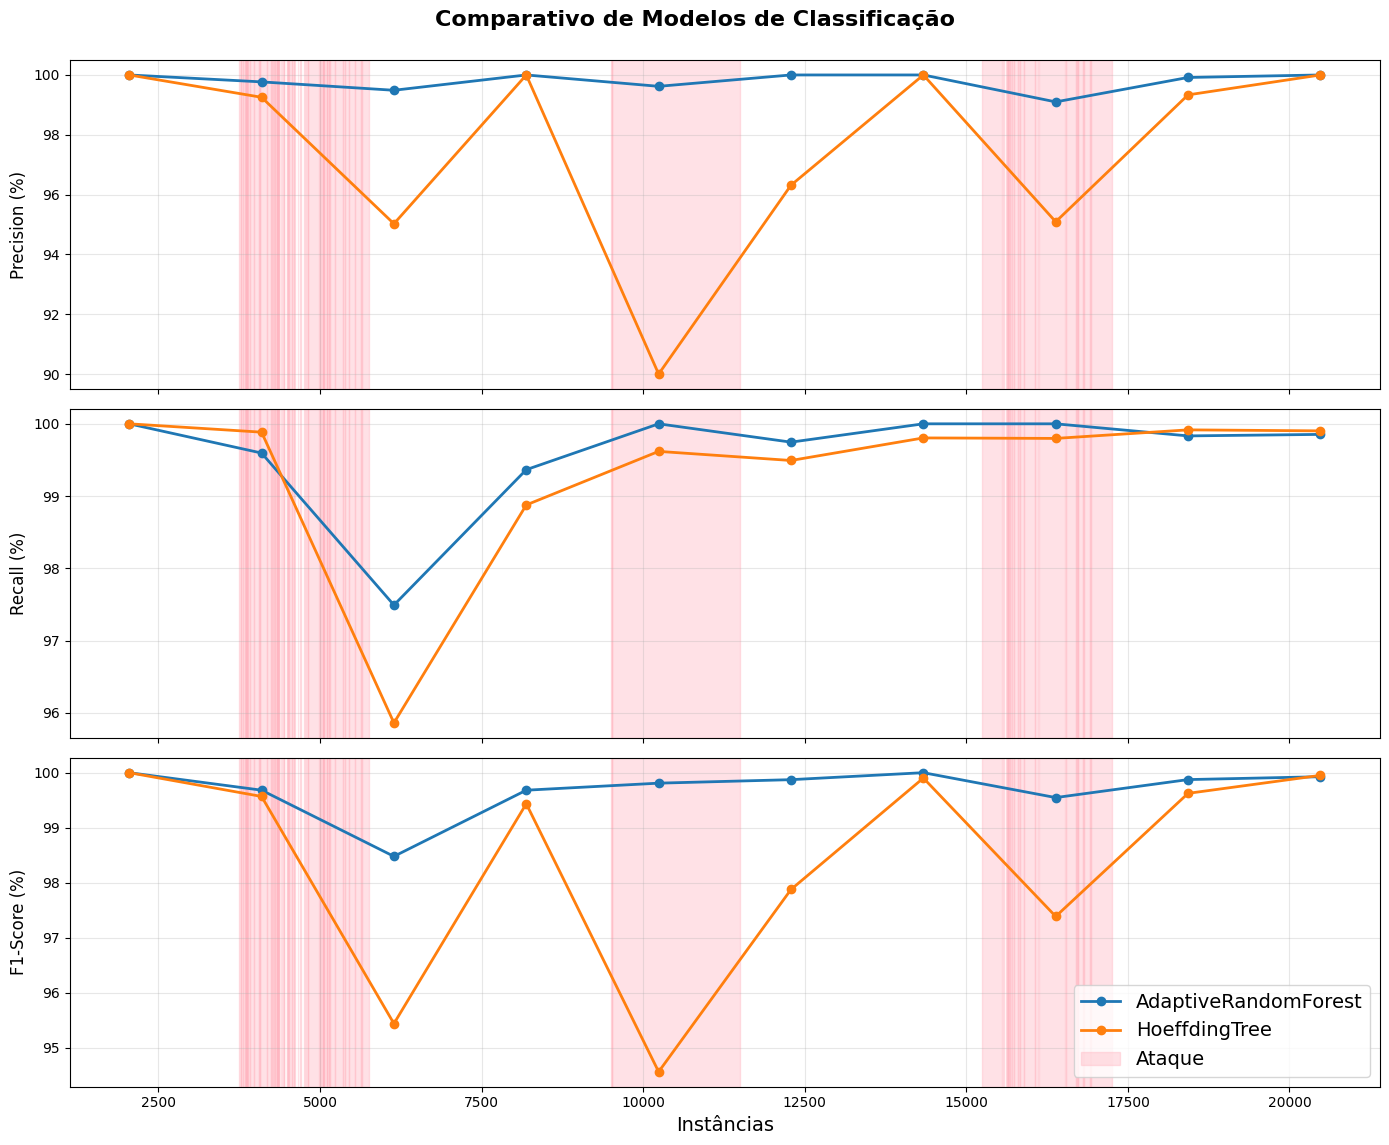

In [ ]:
%load_ext autoreload
%autoreload 2

from src.Classification.Models import get_classification_models
from src.Classification.Pipeline import ClassificationExperimentRunner
from src.Data.Processor import DataStreamProcessor
import pandas as pd

# Instancia o objeto
processor = DataStreamProcessor(logging=False)
runner = ClassificationExperimentRunner()

# df = pd.read_csv('data/15k/Adaptação/Adaptação_25.csv')
# df = pd.read_csv('data/15k/Adaptação/Adaptação_250.csv')
# df = pd.read_csv('data/15k/Adaptação/Adaptação_500.csv')
# df = pd.read_csv('data/15k/Adaptação/Adaptação_1000.csv')
df = pd.read_csv('data/15k/Adaptação/Adaptação_2000.csv')

stream, targets, features = processor.create_stream(
    df=df, 
    target_label_col='Label', 
    binary_label=True, 
    normalize_method="StandardScaler", 
    threshold_var=0.001,
    threshold_corr=0.85,
    top_n_features=None,
    return_stream=True,
    extra_ignore_cols=['Source IP', 'Source Port','Destination IP','Destination Port','Protocol'],
    imputation_method='mediana'
)

# Obter modelos
modelos = get_classification_models(stream.get_schema(), selected_models=['ARF', 'HT'])

# Treinar e avaliar os modelos
results, attacks = runner.run_experiments(stream, modelos, window_size=2048, logging=False)
runner.print_metrics(results)
runner.plot(results, attacks, title="Comparativo de Modelos de Classificação")

ARF accuracy = 99.68333333333334
HT accuracy = 99.16666666666667


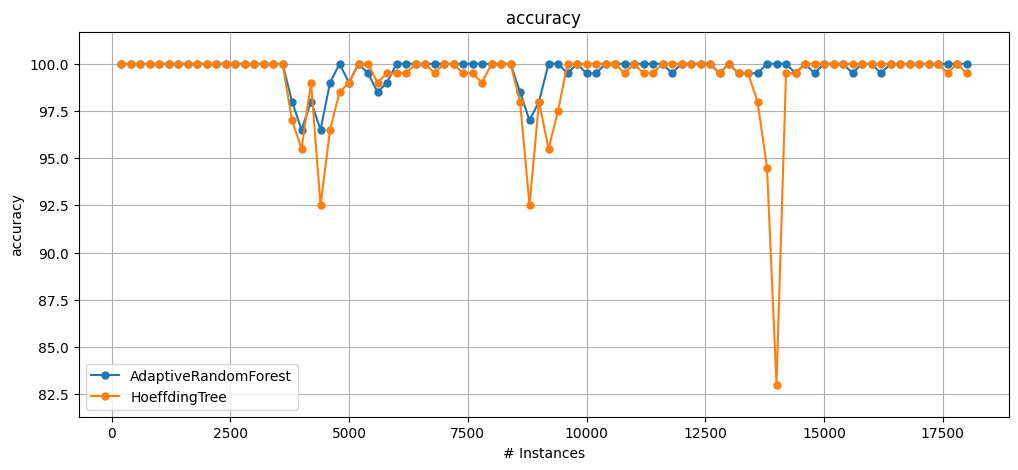

In [2]:
from capymoa.evaluation import prequential_evaluation_multiple_learners
from capymoa.evaluation.visualization import plot_windowed_results
from src.ClassificationModels import get_classification_models
from src.ClassificationPipeline import ClassificationExperimentRunner
from src.DataStreamProcessor import DataStreamProcessor
import pandas as pd

# Instancia o objeto
processor = DataStreamProcessor(logging=False)
runner = ClassificationExperimentRunner()

# df = pd.read_csv('data/15k/Consistência/Consistência_25.csv')
# df = pd.read_csv('data/15k/Consistência/Consistência_250.csv')
# df = pd.read_csv('data/15k/Consistência/Consistência_500.csv')
df = pd.read_csv('data/15k/Consistência/Consistência_1000.csv')
# df = pd.read_csv('data/15k/Consistência/Consistência_2000.csv')

stream, targets, features = processor.create_stream(
    df=df, 
    target_label_col='Label', 
    binary_label=True, 
    normalize_method="StandardScaler", 
    threshold_var=0.001,
    threshold_corr=0.85,
    top_n_features=None,
    return_stream=True,
    extra_ignore_cols=['Source IP', 'Source Port','Destination IP','Destination Port','Protocol'],
    imputation_method='mediana'
)

# Obter modelos
modelos = get_classification_models(stream.get_schema(), selected_models=['ARF', 'HT'])

# Executar avaliação prequential
results = prequential_evaluation_multiple_learners(stream, modelos, window_size=200, max_instances=len(df))

# Exibir resultados
if 'LeveragingBagging' in results:
    print(f"LB accuracy = {results['LeveragingBagging'].cumulative.accuracy()}")

if 'HoeffdingAdaptiveTree' in results:
    print(f"HAT accuracy = {results['HoeffdingAdaptiveTree'].cumulative.accuracy()}")

if 'AdaptiveRandomForest' in results:
    print(f"ARF accuracy = {results['AdaptiveRandomForest'].cumulative.accuracy()}")

if 'HoeffdingTree' in results:
    print(f"HT accuracy = {results['HoeffdingTree'].cumulative.accuracy()}")

plot_windowed_results(*results.values(), metric="accuracy", save_only=False)